In [202]:
from utils import * 
import numpy as np
from typing import NamedTuple
import shutil 
from matplotlib.lines import Line2D
from datetime import datetime
import itertools
import os
import re

%load_ext autoreload 
%autoreload 2

date = datetime.now().strftime("%m_%d_%Y")

%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [203]:
# It seems pretty clear that cluster_1 and cluster_3 proteins interact, though it is not clear how, or if the cluster_1 interaction is compatible
# with the multimer form of cluster_2. For this analysis, I am going to focus on the structure for the bz_10 genes, which seem to have some of the highest ipTM scores. 
# I will aim to address the following questions:
#   (1) Are the predicted contacting residues between cluster_1 and cluster_3 the same in the hexameric structure versus the two monomers?
#   (2) Are there residues between cluster_1 and cluster_3 with high-confidence contact in the hexameric structure? 
#   (3) Are the contacting residues conserved in different genomes?
#   (4) Does the structure change in the presence or absence of ligands?

In [ ]:
DSSP_OUTPUT_DIR = '../data/genes/dssp/'

ALPHAFOLD_DIR = '../data/genes/alphafold/'
ALPHAFOLD_INPUT_DIR = '../data/genes/alphafold/af_input/'
ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output/'

MMSEQS_DIR = '../data/genes/mmseqs'
MMSEQS_DATABASE_DIR = '../data/genes/mmseqs/db'
MMSEQS_TMP_DIR = '../data/tmp'


In [205]:
def get_msas_unpaired(gene_ids:list, dir_path:str=MMSEQS_DIR):
    '''Load the unpaired MSAs for the specified gene IDs.
    
    :param gene_ids: The IDs of the genes to construct paired MSAs for. These should all be from the same genome.   
    :param dir_path: The path to the directory where the MSAs are stored. This function assumes the a3m files have names matching the gene ID of the query 
        sequence. 
    '''
    paths = {gene_id:os.path.join(dir_path, f'{gene_id}.a3m') for gene_id in gene_ids}
    return {gene_id:str(FASTAFile.from_file(path)) for gene_id, path in paths.items()}


def get_msas_paired(gene_ids:list, dir_path:str=MMSEQS_DIR):
    '''Construct paired MSAs using the specified gene IDs as queries. This is done by:
        (1) Loading the unpaired MSA for each query gene ID. 
        (2) Filtering each unpaired MSA to include only genes from genomes which are represented in both, i.e. contain identified homologs of each query sequence. 
        (3) Sorting the MSAs alphabetically by gene ID (ensuring the query is still the first entry) so that rows correspond.
        
    :param gene_ids: The IDs of the genes to construct paired MSAs for. These should all be from the same genome.   
    :param dir_path: The path to the directory where the MSAs are stored. This function assumes the a3m files have names matching the gene ID of the query 
        sequence. 
    '''
    assert len(set([get_genome_id(gene_id) for gene_id in gene_ids])) == 1, 'get_msas_paired: Expected all genes to be from the same genome.'

    paths = {gene_id:os.path.join(dir_path, f'{gene_id}.a3m') for gene_id in gene_ids}
    msas = {gene_id:FASTAFile.from_file(path).to_df().reset_index(names='gene_id') for gene_id, path in paths.items()}
    msas = {gene_id:df.assign(genome_id=df.gene_id.apply(get_genome_id)) for gene_id, df in msas.items()}

    genome_ids = None
    for _, df in msas.items(): # Get all genome IDs which have a representative for all chains. 
        genome_ids = df.genome_id.unique() if (genome_ids is None) else np.intersect1d(genome_ids, df.genome_id.unique())
    
    if len(genome_ids) < 2:
        # If there are two few genome IDs, the paired MSA will just contain the genes from the query genome (but do not want it to throw an error). 
        print('get_msas_paired: Too few paired sequences for a proper paired MSA.')

    sort = lambda df : pd.concat([df.iloc[:1], df.iloc[1:].sort_values('gene_id')]) # Sort a DataFrame by genome ID, while holding the query row fixed.
    msas = {gene_id:sort(df[df.genome_id.isin(genome_ids)].copy()) for gene_id, df in msas.items()}
    
    return {gene_id:str(FASTAFile.from_df(df.set_index('gene_id'))) for gene_id, df in msas.items()}


In [206]:
genome_id = 'bz_10'

In [207]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df = genes_df[genes_df.genome_id != 'bz_12'].copy()
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r'))).astype(int)
genes_df['gene_id'] = genes_df.index.values
genes_df = genes_df[genes_df.cluster_id.isin([1, 3])].copy()
genes_df['alphafold_id'] = genes_df.apply(lambda row : f'{row.genome_id}_cluster_{row.cluster_id}' + '_{n}mer', axis=1)

CLUSTER_1_SEQS = genes_df[genes_df.cluster_id == 1].set_index('genome_id').seq.to_dict()
CLUSTER_3_SEQS = genes_df[genes_df.cluster_id == 3].set_index('genome_id').seq.to_dict()

CLUSTER_1_GENE_IDS = genes_df[genes_df.cluster_id == 1].set_index('genome_id').gene_id.to_dict()
CLUSTER_3_GENE_IDS = genes_df[genes_df.cluster_id == 3].set_index('genome_id').gene_id.to_dict()

In [208]:
path = os.path.join(ALPHAFOLD_INPUT_DIR, 'cluster_1-cluster_3.json')
counts = [(1, 1), (1, 6), (3, 6), (12, 6), (6, 6)] # Counts for the cluster_1 and cluster_3 subunits, respectively. 

inputs = list()
for genome_id, df in genes_df[genes_df.genome_id == genome_id].groupby('genome_id'):
    df = df.sort_values('cluster_id') # Make sure cluster_1 is first. 
    cluster_1_entry = df[df.cluster_id == 1].iloc[0]
    cluster_3_entry = df[df.cluster_id == 3].iloc[0]

    for (cluster_1_count, cluster_3_count), ligand in itertools.product(counts, ['adp', 'atp', None]):

        name = cluster_1_entry.alphafold_id.format(n=cluster_1_count) + '-' + cluster_3_entry.alphafold_id.format(n=cluster_3_count)
        if ligand is not None:
            name = name + f'-mg_{ligand}'

        msas = dict()
        msas['paired'] = get_msas_paired(df.gene_id.values)
        msas['unpaired'] = get_msas_unpaired(df.gene_id.values)

        input = AlphaFoldInputFile(name, dialect='alphafoldserver', num_seeds=1, version=2)

        input.add_seq(cluster_1_entry.seq, paired_msa=msas['paired'][cluster_1_entry.gene_id], unpaired_msa=msas['unpaired'][cluster_1_entry.gene_id], n=cluster_1_count)
        input.add_seq(cluster_3_entry.seq, paired_msa=msas['paired'][cluster_3_entry.gene_id], unpaired_msa=msas['unpaired'][cluster_3_entry.gene_id], n=cluster_3_count)
        if ligand is not None:
            input._add_ligand(type_=ligand, n=cluster_1_count)

        print(f'Generated input for {input.name}.')
        inputs.append(input)

with open(path, 'w') as f:
    json.dump([input.get_info() for input in inputs], f)

output_dirs = [os.path.join(ALPHAFOLD_DIR, 'fold_' + input.name.replace('-', '_')) for input in inputs]
outputs = [AlphaFoldServerOutput(path) for path in output_dirs if os.path.exists(path)]

Generated input for bz_10_cluster_1_1mer-bz_10_cluster_3_1mer-mg_adp.
Generated input for bz_10_cluster_1_1mer-bz_10_cluster_3_1mer-mg_atp.
Generated input for bz_10_cluster_1_1mer-bz_10_cluster_3_1mer.
Generated input for bz_10_cluster_1_1mer-bz_10_cluster_3_6mer-mg_adp.
Generated input for bz_10_cluster_1_1mer-bz_10_cluster_3_6mer-mg_atp.
Generated input for bz_10_cluster_1_1mer-bz_10_cluster_3_6mer.
Generated input for bz_10_cluster_1_3mer-bz_10_cluster_3_6mer-mg_adp.
Generated input for bz_10_cluster_1_3mer-bz_10_cluster_3_6mer-mg_atp.
Generated input for bz_10_cluster_1_3mer-bz_10_cluster_3_6mer.
Generated input for bz_10_cluster_1_12mer-bz_10_cluster_3_6mer-mg_adp.
Generated input for bz_10_cluster_1_12mer-bz_10_cluster_3_6mer-mg_atp.
Generated input for bz_10_cluster_1_12mer-bz_10_cluster_3_6mer.
Generated input for bz_10_cluster_1_6mer-bz_10_cluster_3_6mer-mg_adp.
Generated input for bz_10_cluster_1_6mer-bz_10_cluster_3_6mer-mg_atp.
Generated input for bz_10_cluster_1_6mer-bz_1

In [209]:
data = dict()

def get_interface_chain_ids(output, contact_probs_df:pd.DataFrame):
    '''Find two chains from different groups which are predicted to have at least one pair of contacting residues.'''
    # Based on how the input was formatted, the chains in the first group should be cluster_1.  
    for chain_ids in list(itertools.product(*output.get_chain_ids(group=True))): # Separated into groups according to sequence.
        if has_interface(contact_probs_df, chain_ids, min_contact_prob=0.5)[1]:
            return chain_ids
    # print(f'get_interface_chain_ids: No interface found for {output.name}')
    return None 

# for output in outputs:
for output in outputs:
    contact_probs_df = output.get_contact_probs(models=[output.best_model])
    paes_df =  output.get_paes(models=[output.best_model])
    chain_ids = get_interface_chain_ids(output, contact_probs_df)
    if chain_ids is None:
        print(f'No interface found for {output.name}')
        continue

    idxs, idxs_shifted = get_interface_idxs(contact_probs_df, chain_ids=chain_ids, shift=True)
    idxs = [idxs[chain_ids[0]], idxs[chain_ids[1]]]

    data_ = {'name':output.name}
    data_['iptm'] = np.mean(list(output.get_iptms().values()))
    data_['idxs'] = idxs
    data_['idxs_shifted'] = [idxs_shifted[chain_ids[0]], idxs_shifted[chain_ids[1]]]
    data_['num_contacts'] = len(idxs[0])
    data_['pae'] = [paes_df.iloc[i, j] for i, j in zip(*idxs)]
    data_['contact_probs'] = [contact_probs_df.iloc[i, j] for i, j in zip(*idxs)]
    data[output.name] = data_

# Also want to take a look at the PAE distribution. 

No interface found for fold_bz_10_cluster_1_1mer_bz_10_cluster_3_6mer_mg_adp
No interface found for fold_bz_10_cluster_1_1mer_bz_10_cluster_3_6mer_mg_atp
No interface found for fold_bz_10_cluster_1_1mer_bz_10_cluster_3_6mer


Number of contacts for cluster_1_1mer_cluster_3_1mer_mg_adp with > 70% probability: 17
Number of contacts for cluster_1_1mer_cluster_3_1mer_mg_atp with > 70% probability: 15
Number of contacts for cluster_1_1mer_cluster_3_1mer with > 70% probability: 18
Number of contacts for cluster_1_3mer_cluster_3_6mer_mg_adp with > 70% probability: 0
Skipping cluster_1_3mer_cluster_3_6mer_mg_adp, only one contact found.
Number of contacts for cluster_1_3mer_cluster_3_6mer_mg_atp with > 70% probability: 0
Number of contacts for cluster_1_3mer_cluster_3_6mer with > 70% probability: 0
Skipping cluster_1_3mer_cluster_3_6mer, only one contact found.
Number of contacts for cluster_1_12mer_cluster_3_6mer_mg_adp with > 70% probability: 0
Number of contacts for cluster_1_12mer_cluster_3_6mer_mg_atp with > 70% probability: 0
Number of contacts for cluster_1_12mer_cluster_3_6mer with > 70% probability: 0
Number of contacts for cluster_1_6mer_cluster_3_6mer_mg_adp with > 70% probability: 3
Number of contacts f

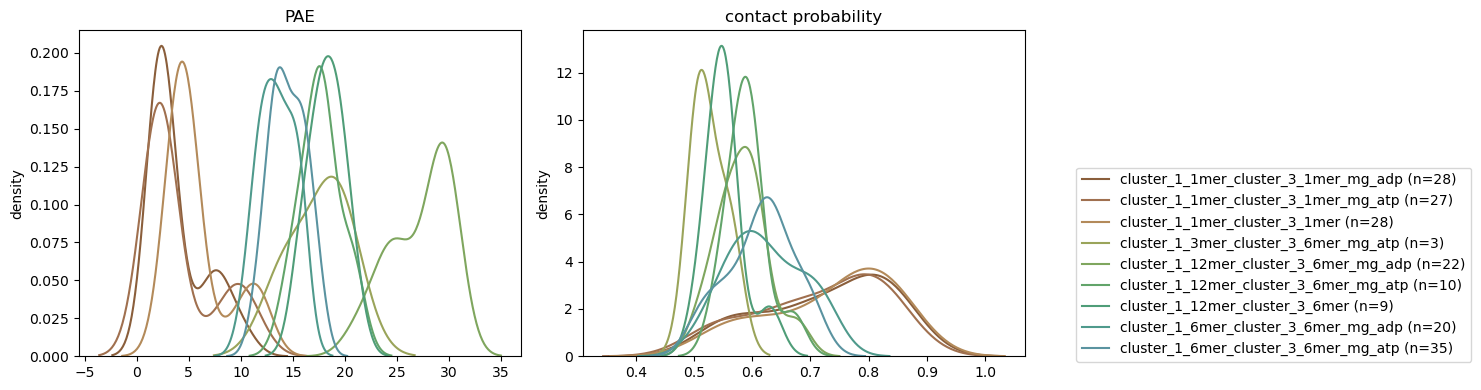

In [210]:
fig, axes = plt.subplots(ncols=2, figsize=(15, 4), sharey=False)

keep = lambda name : (genome_id in name)

for data_ in data.values():

    if not keep(data_['name']):
        continue 
    name = data_['name'].replace(f'fold_{genome_id}_', '').replace(f'{genome_id}_', '')


    n = data_['num_contacts']

    # print(f'Maximum contact probability for {name}:', max(data_['contact_probs']))
    print(f'Number of contacts for {name} with > 70% probability:', (np.array(data_['contact_probs']) > 0.7).sum())
    if len(data_['pae']) < 2:
        print(f'Skipping {name}, only one contact found.')
        continue

    sns.kdeplot(data_['pae'], label=f'{name} (n={n})', ax=axes[0])
    sns.kdeplot(data_['contact_probs'], label=f'{name} (n={n})', ax=axes[1])

axes[1].legend(bbox_to_anchor=(1.1, 0.6))

axes[0].set_ylabel('density')
axes[1].set_ylabel('density')

axes[0].set_title('PAE')
axes[1].set_title('contact probability')

fig.tight_layout()
plt.show()


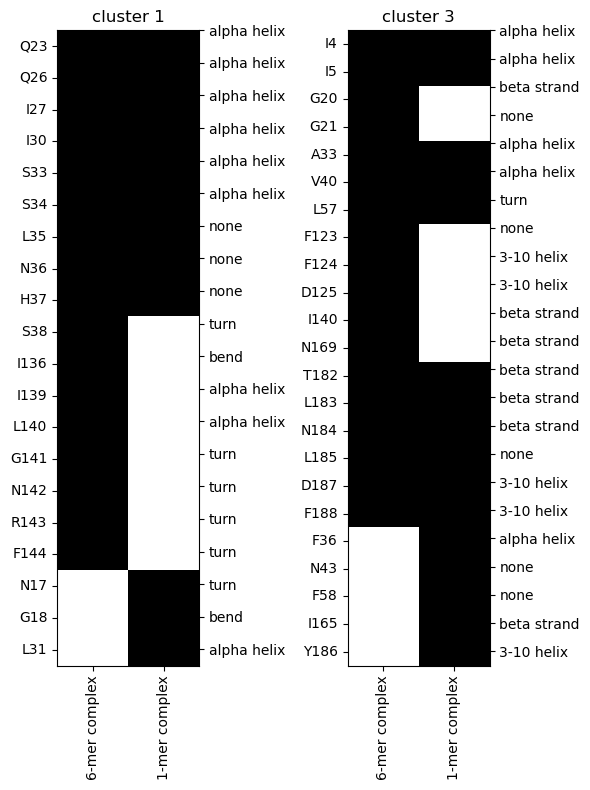

In [211]:

cluster_1_gene_id = CLUSTER_1_GENE_IDS[genome_id]
cluster_3_gene_id = CLUSTER_3_GENE_IDS[genome_id]

dssp_df = [DSSPFile.from_file(os.path.join(DSSP_OUTPUT_DIR, f'{cluster_1_gene_id}.dssp')).to_df().assign(cluster_id=1)]
dssp_df += [DSSPFile.from_file(os.path.join(DSSP_OUTPUT_DIR, f'{cluster_3_gene_id}.dssp')).to_df().assign(cluster_id=3)]
dssp_df = pd.concat(dssp_df).rename(columns={'residue':'idx', 'aa':'residue'}).drop(columns=['chain', 'code'])
dssp_df['idx'] = dssp_df['idx'] - 1 # Need to shift the index to be zero-indexed. 

figure_df = pd.DataFrame()

for name in [f'fold_{genome_id}_cluster_1_6mer_{genome_id}_cluster_3_6mer_mg_atp', f'fold_{genome_id}_cluster_1_1mer_{genome_id}_cluster_3_1mer_mg_atp']:

    contacts = dict()
    contacts[1] = np.unique(data[name]['idxs_shifted'][0])
    contacts[3] = np.unique(data[name]['idxs_shifted'][1])

    for cluster_id, idxs in contacts.items():
        for idx in idxs:
            residue = CLUSTER_1_SEQS[genome_id][idx] if (cluster_id == 1) else CLUSTER_3_SEQS[genome_id][idx]
            figure_df.loc[f'{residue}{idx}', name] = True
            figure_df.loc[f'{residue}{idx}', 'idx'] = idx
            figure_df.loc[f'{residue}{idx}', 'residue'] = residue
            figure_df.loc[f'{residue}{idx}', 'cluster_id'] = cluster_id

figure_df = figure_df.fillna(False)
index = figure_df.index.copy()
figure_df = figure_df.merge(dssp_df, on=['cluster_id', 'idx', 'residue'], how='left')
figure_df.index = index

fig, axes = plt.subplots(ncols=2, figsize=(6, 8))

label_map = dict()
label_map[f'fold_{genome_id}_cluster_1_6mer_{genome_id}_cluster_3_6mer_mg_atp'] = '6-mer complex'
label_map[f'fold_{genome_id}_cluster_1_1mer_{genome_id}_cluster_3_1mer_mg_atp'] = '1-mer complex'

for ax, (cluster_id, df) in zip(axes, figure_df.groupby('cluster_id')):
    sns.heatmap(df[list(label_map.keys())].astype(int), ax=ax, cbar=False, cmap='binary')
    ax.set_title(f'cluster {int(cluster_id)}')
    ax.twinx().set_yticks(ax.get_yticks(), labels=df.structure.values[::-1])
    ax.set_xticks(ax.get_xticks(), labels=[label_map.get(label.get_text()) for label in ax.get_xticklabels()])

fig.tight_layout()
plt.show()

In [212]:
print(list(label_map.keys()))

['fold_bz_10_cluster_1_6mer_bz_10_cluster_3_6mer_mg_atp', 'fold_bz_10_cluster_1_1mer_bz_10_cluster_3_1mer_mg_atp']


In [213]:
# DSSP_OUTPUT_DIR = '../data/genes/dssp/'
# DSSP_INPUT_DIR = '../data/genes/dssp/structures/cluster_3/'

# copy_structures(list(CLUSTER_3_GENE_IDS.values()), source_dir='../data/genes/colabfold', output_dir=DSSP_INPUT_DIR)

# for path in glob.glob(os.path.join(DSSP_INPUT_DIR, '*')):
#     gene_id = get_gene_id(path)
#     output_path = os.path.join(DSSP_OUTPUT_DIR, f'{gene_id}.dssp')
#     if not os.path.exists(output_path):
#         subprocess.run(f'mkdssp {path} {output_path} --output-format dssp', shell=True, check=True)


In [214]:
msa = MSA.from_file('../data/genes/cluster_1.afa')







In [215]:
properties = {'hydrophobic': ['ALA', 'VAL', 'LEU', 'ILE', 'MET', 'PRO'], 'aromatic': ['PHE', 'TRP', 'TYR'], 'polar': ['SER', 'THR', 'ASN', 'GLN', 'CYS'], 'positive': ['ARG', 'LYS', 'HIS'], 'negative': ['ASP', 'GLU'], 'special': ['GLY']}
palette = {'hydrophobic': 'goldenrod', 'aromatic': 'purple', 'polar': 'forestgreen', 'positive': 'cornflowerblue', 'negative': 'tomato', 'special': 'gray'}
palette = {'hydrophobic': 'gray', 'aromatic': 'forestgreen', 'polar': 'gray', 'positive': 'cornflowerblue', 'negative': 'gray', 'special': 'gray'}

cmd = []
for property, residues in properties.items():
    residues = ','.join([residue.lower() for residue in residues])
    color = palette[property]
    cmd += [f'sel :{residues}; color sel {color}']
print('; '.join(cmd))

sel :ala,val,leu,ile,met,pro; color sel gray; sel :phe,trp,tyr; color sel forestgreen; sel :ser,thr,asn,gln,cys; color sel gray; sel :arg,lys,his; color sel cornflowerblue; sel :asp,glu; color sel gray; sel :gly; color sel gray


In [216]:
# NOTE: I can't get the paired MSAs to work on the AlphaFold server for some reason, even when combining them (I also tried adding both individually). 

# path = os.path.join(ALPHAFOLD_INPUT_DIR, f'{genome_id}_cluster_3_6mer-{genome_id}_cluster_1_6mer-mg_atp.json')
# name = os.path.basename(path).replace('.json', '')

# with open(path, 'r') as f:
#     input = json.load(f)[0]

# paired_msas = [input['sequences'][0]['proteinChain']['pairedMsa'], input['sequences'][1]['proteinChain']['pairedMsa']]
# paired_msas = [paired_msa.split('\n') for paired_msa in paired_msas]
# paired_msa = [''.join(lines) for lines in zip(*paired_msas)]

# get_header = lambda line : '>' + '-'.join(line[1:].split('>'))
# paired_msa = [get_header(line) if line.startswith('>') else line for line in paired_msa]
# paired_msa = '\n'.join(paired_msa)

# with open(os.path.join(ALPHAFOLD_DIR, f'{name}_paired_msa.af3'), 'w') as f:
#     f.write(paired_msa)
# print(paired_msa)